In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
data=pd.read_csv("C://Users//MAYUR MAKVANA//OneDrive//Desktop//files//owid-covid-data.csv")
print(data.info())
copy_data=data.copy()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    429435 non-null  object 
 1   continent                                   402910 non-null  object 
 2   location                                    429435 non-null  object 
 3   date                                        429435 non-null  object 
 4   total_cases                                 411804 non-null  float64
 5   new_cases                                   410159 non-null  float64
 6   new_cases_smoothed                          408929 non-null  float64
 7   total_deaths                                411804 non-null  float64
 8   new_deaths                                  410608 non-null  float64
 9   new_deaths_smoothed                         409378 non-null  float64
 

In [ ]:
copy_data=copy_data[["location","date","total_cases","new_cases",
                     "total_deaths","new_deaths","population"]].copy()
print(copy_data)

           location        date  total_cases  new_cases  total_deaths  \
0       Afghanistan  2020-01-05          0.0        0.0           0.0   
1       Afghanistan  2020-01-06          0.0        0.0           0.0   
2       Afghanistan  2020-01-07          0.0        0.0           0.0   
3       Afghanistan  2020-01-08          0.0        0.0           0.0   
4       Afghanistan  2020-01-09          0.0        0.0           0.0   
...             ...         ...          ...        ...           ...   
429430     Zimbabwe  2024-07-31     266386.0        0.0        5740.0   
429431     Zimbabwe  2024-08-01     266386.0        0.0        5740.0   
429432     Zimbabwe  2024-08-02     266386.0        0.0        5740.0   
429433     Zimbabwe  2024-08-03     266386.0        0.0        5740.0   
429434     Zimbabwe  2024-08-04     266386.0        0.0        5740.0   

        new_deaths  population  
0              0.0    41128772  
1              0.0    41128772  
2              0.0    41

In [ ]:
copy_data=copy_data.dropna(subset=["total_cases","total_deaths"]).copy()
copy_data["new_cases"]=copy_data["new_cases"].fillna(0)
copy_data["new_deaths"]=copy_data["new_deaths"].fillna(0)
print(copy_data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 411804 entries, 0 to 429434
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   location      411804 non-null  object 
 1   date          411804 non-null  object 
 2   total_cases   411804 non-null  float64
 3   new_cases     411804 non-null  float64
 4   total_deaths  411804 non-null  float64
 5   new_deaths    411804 non-null  float64
 6   population    411804 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 25.1+ MB
None


In [ ]:
copy_data["date"]=pd.to_datetime(copy_data["date"])
cols=["total_cases","new_cases","total_deaths","new_deaths"]
copy_data[cols]=copy_data[cols].astype(int)
print(copy_data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 411804 entries, 0 to 429434
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   location      411804 non-null  object        
 1   date          411804 non-null  datetime64[ns]
 2   total_cases   411804 non-null  int32         
 3   new_cases     411804 non-null  int32         
 4   total_deaths  411804 non-null  int32         
 5   new_deaths    411804 non-null  int32         
 6   population    411804 non-null  int64         
dtypes: datetime64[ns](1), int32(4), int64(1), object(1)
memory usage: 18.9+ MB
None


In [ ]:
world=copy_data[copy_data["location"]=="World"]
print(world)
world.to_csv("C://Users//MAYUR MAKVANA//OneDrive//Desktop//world.csv",index=False)

       location       date  total_cases  new_cases  total_deaths  new_deaths  \
422729    World 2020-01-05            2          2             3           3   
422730    World 2020-01-06            2          0             3           0   
422731    World 2020-01-07            2          0             3           0   
422732    World 2020-01-08            2          0             3           0   
422733    World 2020-01-09            2          0             3           0   
...         ...        ...          ...        ...           ...         ...   
424398    World 2024-07-31    775819614          0       7056317           0   
424399    World 2024-08-01    775819614          0       7056317           0   
424400    World 2024-08-02    775819614          0       7056317           0   
424401    World 2024-08-03    775819614          0       7056317           0   
424402    World 2024-08-04    775866783      47169       7057132         815   

        population  
422729  7975105024

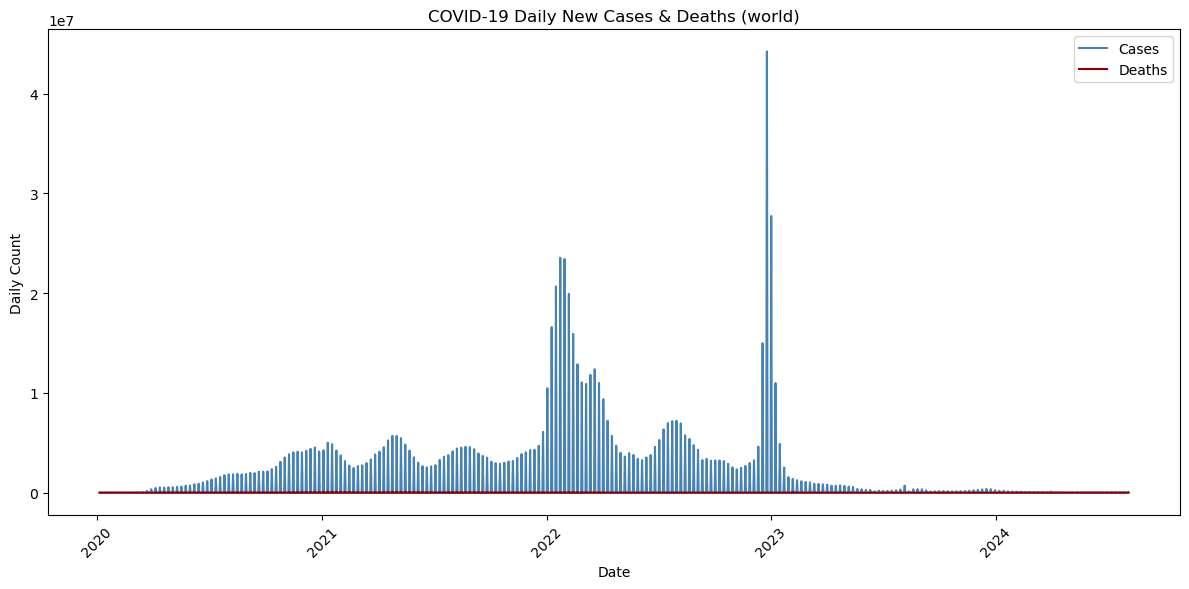

In [ ]:
plt.figure(figsize=(12,6))

# Daily new cases
plt.plot(world["date"], world["new_cases"], label="Cases", color="steelblue")

# Daily new deaths
plt.plot(world["date"], world["new_deaths"], label="Deaths", color="darkred")

# Labels and title
plt.xlabel("Date")
plt.ylabel("Daily Count")
plt.title("COVID-19 Daily New Cases & Deaths (world)")
plt.legend()
plt.savefig("C://Users//MAYUR MAKVANA//OneDrive//Desktop//project chart//world1.png")
# Rotate x-axis
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

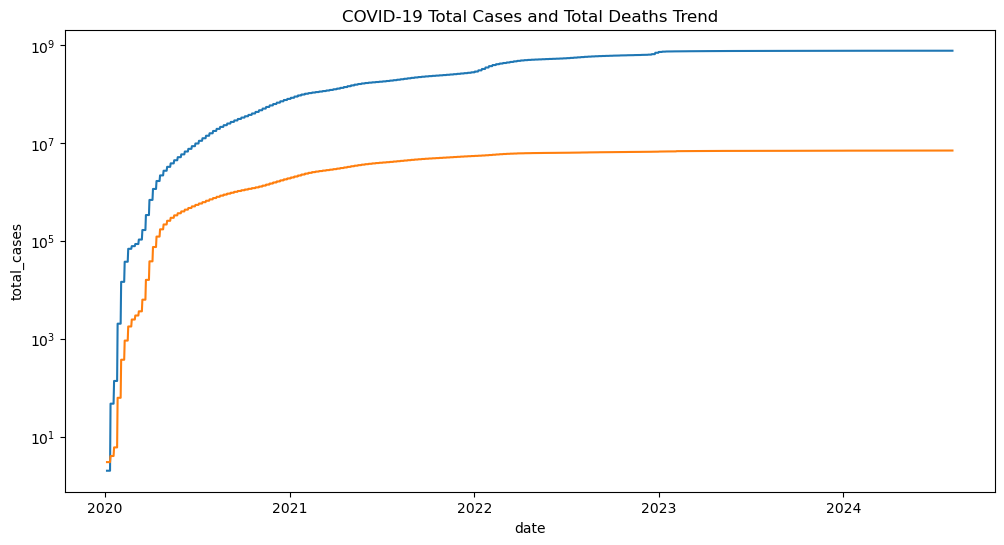

In [ ]:
plt.figure(figsize=(12,6))
sns.lineplot(data=world,x="date",y="total_cases")
sns.lineplot(data=world,x="date",y="total_deaths")
plt.yscale("log")
plt.savefig("C://Users//MAYUR MAKVANA//OneDrive//Desktop//project chart//world2.png")
plt.title("COVID-19 Total Cases and Total Deaths Trend")
plt.show()

In [ ]:
last=copy_data[copy_data["date"]==copy_data["date"].max()]
world=last[last["location"]=="World"]
print(world)

       location       date  total_cases  new_cases  total_deaths  new_deaths  \
424402    World 2024-08-04    775866783      47169       7057132         815   

        population  
424402  7975105024  


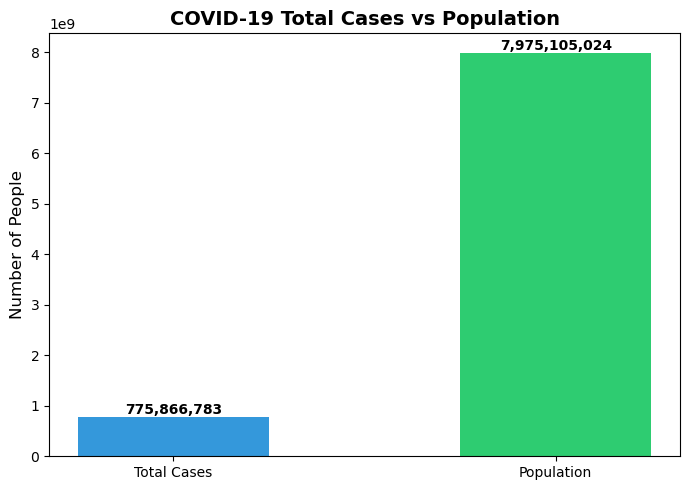

In [ ]:
labels = ["Total Cases", "Population"]
values = [775866783, 7975105024]
# Plot bar chart
plt.figure(figsize=(7,5))
bars = plt.bar(labels, values, color=["#3498db", "#2ecc71"], width=0.5)

# Add labels above bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:,}",
             ha="center", va="bottom", fontsize=10, fontweight="bold")

# Titles and labels
plt.title("COVID-19 Total Cases vs Population", fontsize=14, fontweight="bold")
plt.ylabel("Number of People", fontsize=12)
plt.savefig("C://Users//MAYUR MAKVANA//OneDrive//Desktop//project chart//world3.png")
plt.tight_layout()
plt.show()

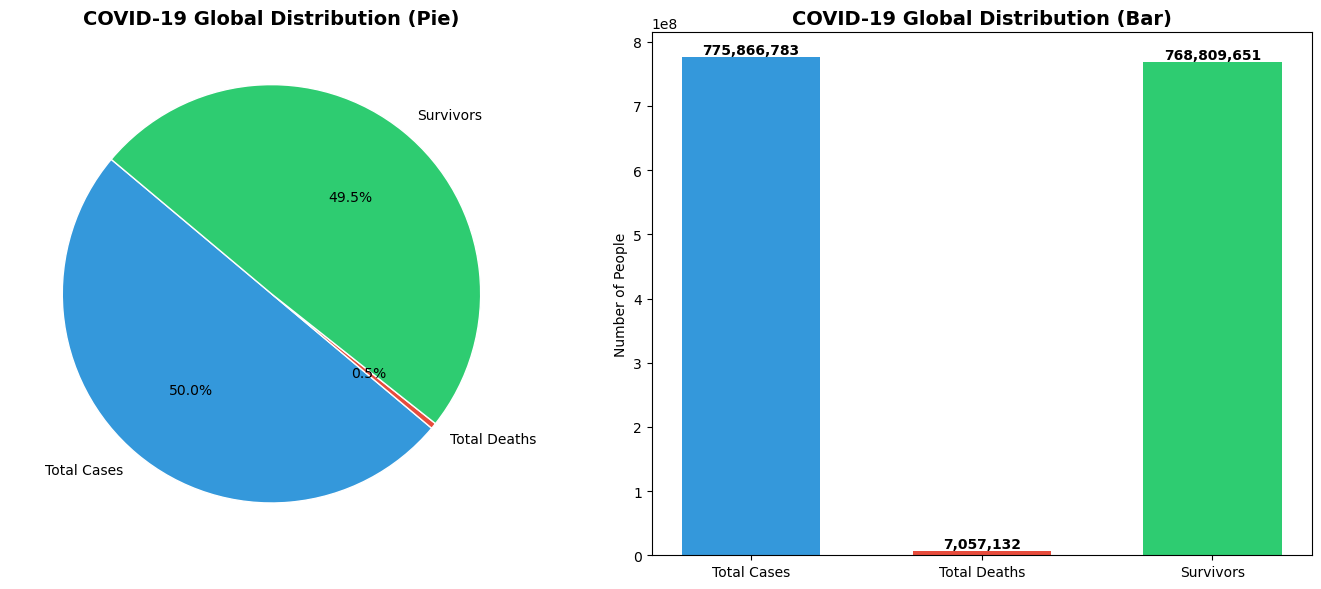

In [ ]:
labels = ["Total Cases", "Total Deaths", "Survivors"]
total_cases = 775866783
total_deaths = 7057132
survivors = total_cases - total_deaths

values = [total_cases, total_deaths, survivors]

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Pie chart
axes[0].pie(values, labels=labels, autopct='%1.1f%%', startangle=140,
            colors=["#3498db", "#e74c3c", "#2ecc71"], wedgeprops={'edgecolor':'white'})
axes[0].set_title("COVID-19 Global Distribution (Pie)", fontsize=14, fontweight="bold")

# Bar chart
bars = axes[1].bar(labels, values, color=["#3498db", "#e74c3c", "#2ecc71"], width=0.6)
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height, f"{height:,}",
                 ha='center', va='bottom', fontsize=10, fontweight="bold")
axes[1].set_title("COVID-19 Global Distribution (Bar)", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Number of People")
plt.savefig("C://Users//MAYUR MAKVANA//OneDrive//Desktop//project chart//world4.png")
plt.tight_layout()
plt.show()
